Clean dataset saved as clean_dataset.csv
   ID  Name       Age    Salary JoiningDate  PerformanceScore  Department_HR  \
0   1     4 -0.870388 -0.713831  2023-07-01          0.013889          False   
1   2     6  0.174078  0.178458  2022-03-15          0.708333           True   
2   3     1 -1.566699 -1.606119  2024-01-10          0.222222          False   
3   4     5  0.870388  0.000000  2021-11-20          0.430556          False   
4   5     3 -0.174078 -0.178458  2023-05-05         -1.236111          False   

   Department_IT  Department_Marketing  JoinYear  JoinMonth  TenureDays  
0           True                 False      2023          7        1102  
1          False                 False      2022          3        1575  
2          False                 False      2024          1         909  
3           True                 False      2021         11        1690  
4          False                  True      2023          5        1159  
             ID      Name        A

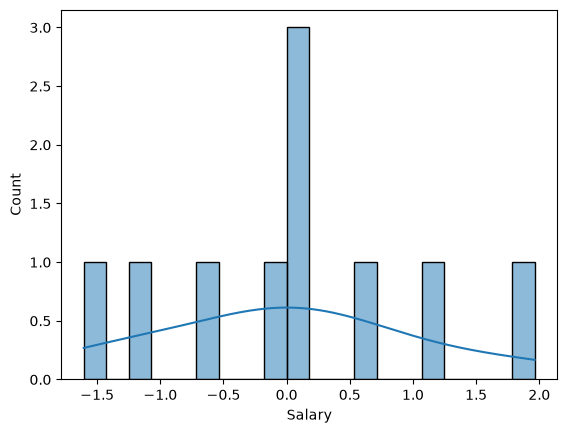

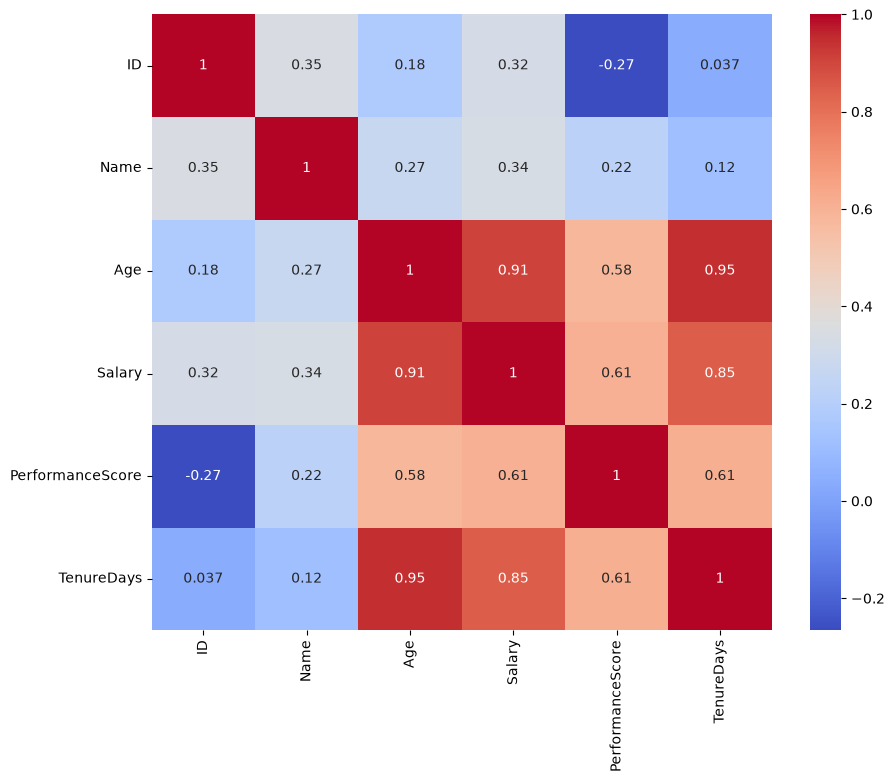

In [4]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Step 2: Load dataset
df = pd.read_csv("sample.csv")

# Step 3: Convert JoiningDate to datetime
df['JoiningDate'] = pd.to_datetime(df['JoiningDate'])

# Step 4: Handle Missing Values (fixed assignment style)
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())
df['PerformanceScore'] = df['PerformanceScore'].fillna(df['PerformanceScore'].median())

# Step 5: Remove Duplicates
df.drop_duplicates(inplace=True)

# Step 6: Encode Categorical Variables
# One-hot encoding for Department
df = pd.get_dummies(df, columns=['Department'], drop_first=True)

# Label encoding for Name
le = LabelEncoder()
df['Name'] = le.fit_transform(df['Name'])

# Step 7: Normalize Numerical Features
scaler = StandardScaler()
df[['Age','Salary','PerformanceScore']] = scaler.fit_transform(df[['Age','Salary','PerformanceScore']])

# Step 8: Add extra date features (optional, for deeper insights)
df['JoinYear'] = df['JoiningDate'].dt.year
df['JoinMonth'] = df['JoiningDate'].dt.month
df['TenureDays'] = (pd.Timestamp.today() - df['JoiningDate']).dt.days

# Step 9: Save Clean Dataset
df.to_csv("clean_dataset.csv", index=False)
print("Clean dataset saved as clean_dataset.csv")

# Step 10: Quick checks
print(df.head())
print(df.describe())
print(df.info())
print("Missing values check:\n", df.isnull().sum())

# Step 11: Visualizations
# Histogram of normalized Salary
sns.histplot(df['Salary'], bins=20, kde=True)
plt.show()

# Correlation heatmap (only numeric columns)
numeric_df = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()
